In [68]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [50]:
np.random.seed(1234)

fields = []

min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in reciprocal
  terms.append((xx/bb[0])**(-a[0]))
/home/m/Documents/science_codes/Kea/Kea/simulator/fbm.py:62: RuntimeWarning: invalid value encountered in multiply
  output = np.sqrt(output * C)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))


In [86]:

models = []

for i, a in enumerate(alphas):
    k, _, _ = spectra_base.calculate_integrated_spectrum((fields[i],), spec_type='modal', lenn=phys_dims)
    models.append(fbm.funcs.smooth_pow(k, (a,), (1.,)))


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

In [51]:

kfeks = []

for f in fields:
    k, fek, _ = spectra_base.calculate_integrated_spectrum((f,), spec_type='modal', lenn=phys_dims)
    kfeks.append((k, fek))


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

In [52]:

sfs = []

for f in fields:
    lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in f.shape])
    sf2 = strfn.process_lags(f, f, lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in f.shape]), orders=[2])[0]
    sfs.append(sf2)


In [53]:

lsf = []

for fs in sfs:
    lvm = statfunc_base.get_lagvec_magnitude_array(fs.shape)
    l, sf, _ = statistics_base.bin_data(lvm, fs, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
    lsf.append((l, sf))


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 fo

In [71]:

k_arevaloz = []

for i, f in enumerate(fields):
    lags = arevalo_spectra.k_to_discrete_lags(kfeks[i][0], N, L)
    k, fek = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags)
    k_arevaloz.append((k, fek))


Text(0.5, 1.0, '-3.824214500038697 - -3.7368421052631575 = -0.0873723947755396')

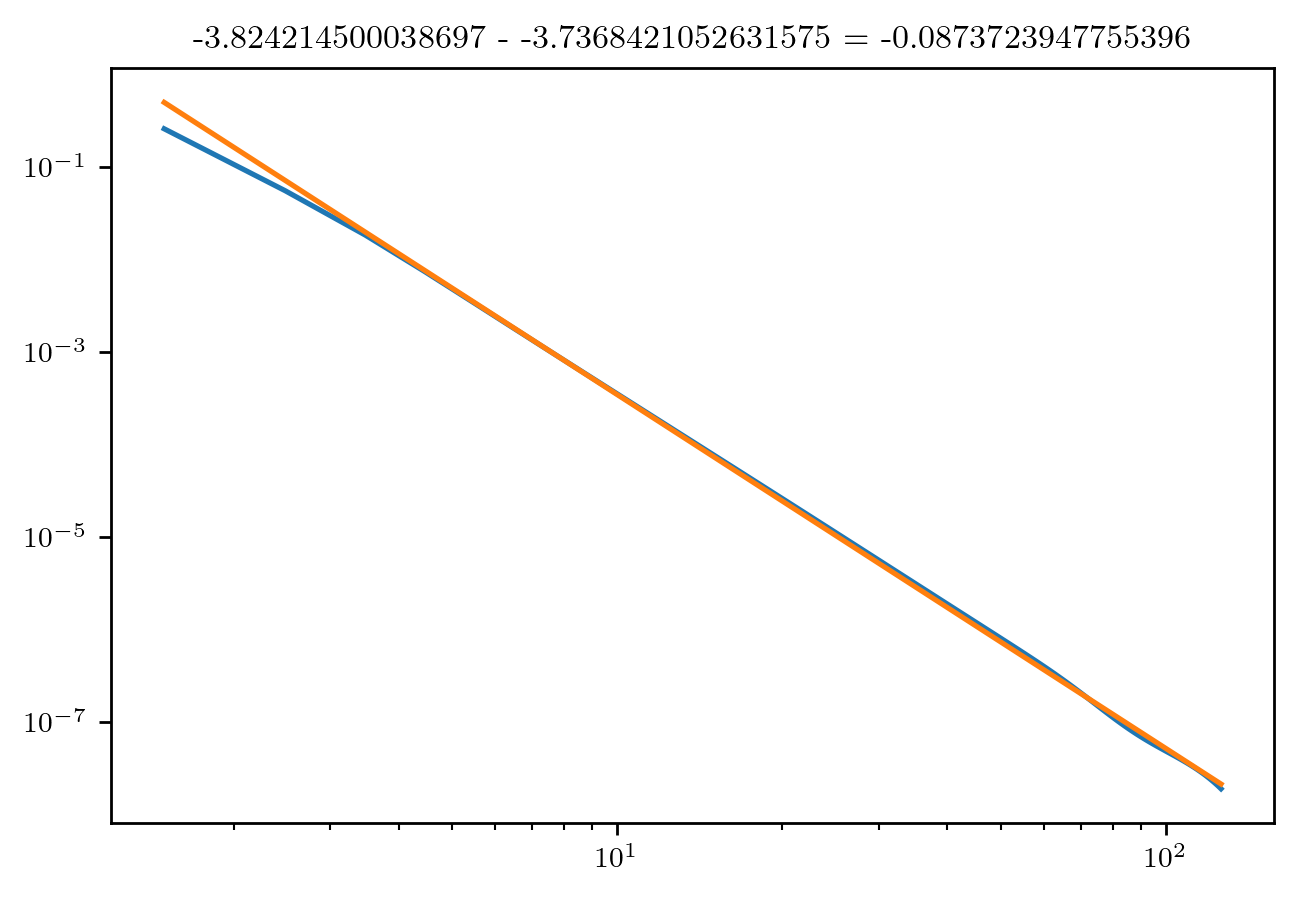

In [72]:
idx = 13
k, fek = k_arevaloz[idx]
plt.loglog(k, fek)
z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
plt.loglog(xx, p)
plt.title('%s - %s = %s' % (z[0], alphas[idx], z[0] - alphas[idx]))

Text(0.5, 1.0, '-2.9623538381037506 - -2.894736842105263 = -0.0676169959984878')

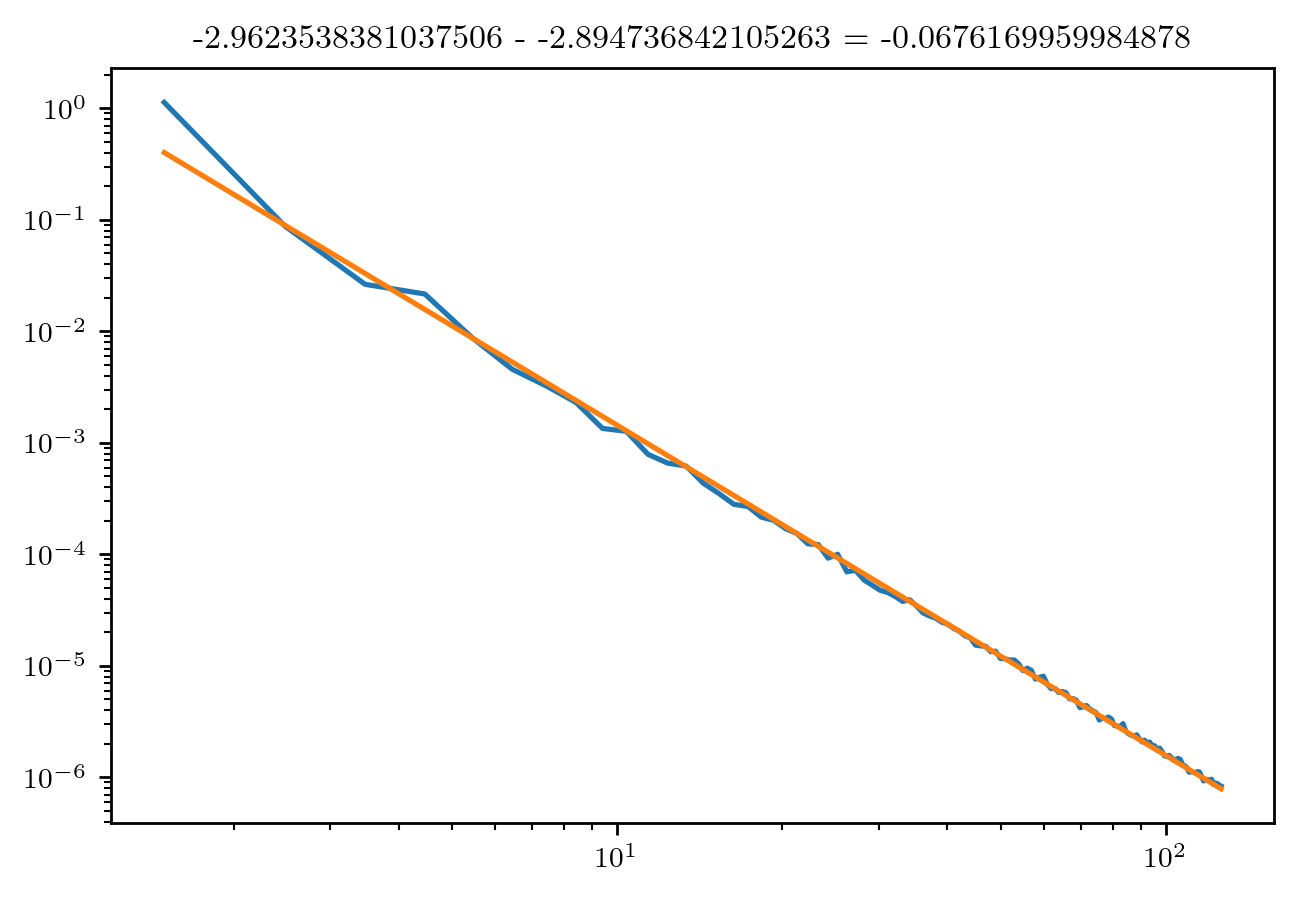

In [54]:
idx = 13
k, fek = kfeks[idx]
plt.loglog(k, fek)
z, xx, p = fit_base.fit_powerlaw(k, fek,np.nanmin(k), np.nanmax(k))
plt.loglog(xx, p)
plt.title('%s - %s = %s' % (z[0], alphas[idx], z[0] - alphas[idx]))

Text(0.5, 1.0, '0.26912266069257623 - 0.05263157894736814 = 0.2164910817452081')

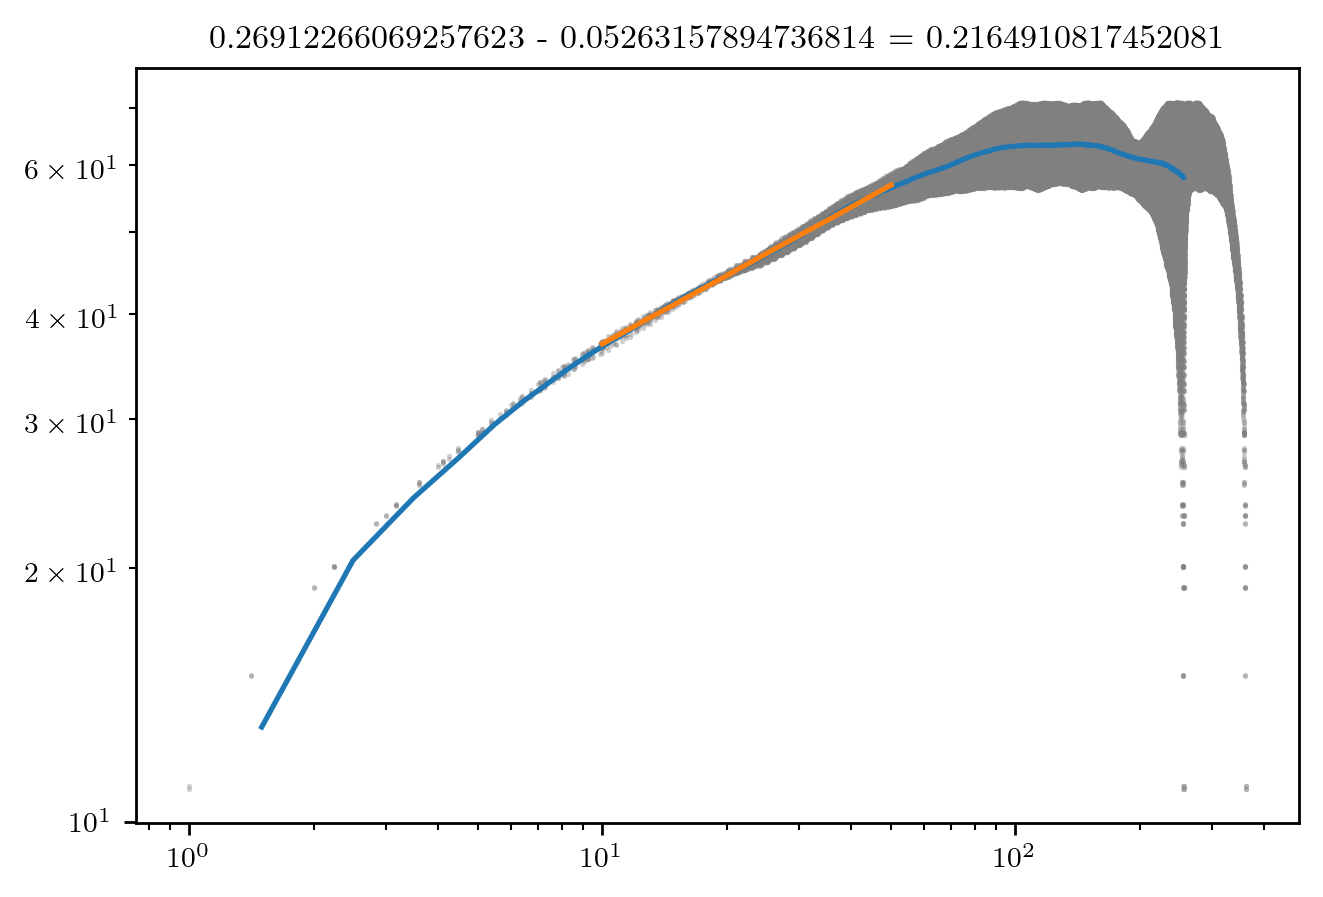

In [80]:
STRFN_MIN, STRFN_MAX = 10., 50.

idx = 5
k, fek = lsf[idx]
plt.scatter(lvm, sfs[idx], alpha=0.2, color='gray', marker='.', s=1.)
plt.loglog(k, fek)
z, xx, p = fit_base.fit_powerlaw(k, fek, STRFN_MIN, STRFN_MAX)
plt.loglog(xx, p)
#z, xx, p = fit_base.fit_powerlaw(k, fek, 2., 10.)
#plt.loglog(xx, p)

# beta = E + 2H
# gamma = 2H
# -> gamma = 2H = beta - E
# for beta \in [E, ..., E + 2] = [2, ..., 4]

beta = - alphas[idx]
plt.title('%s - %s = %s' % (z[0], beta - D, z[0] - (beta - D)))


In [73]:

sf_pwrl = {}

for i, ll in enumerate(lsf):
    l, sf = ll
    z, xx, p = fit_base.fit_powerlaw(l, sf, STRFN_MIN, STRFN_MAX)
    sf_pwrl[-alphas[i]] = (z[0], - alphas[i] - D)

ek_pwrl = {}

for i, kfek in enumerate(kfeks):
    k, fek = kfek
    z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
    ek_pwrl[-alphas[i]] = (z[0], alphas[i])

arevalo_pwrl = {}

for i, kfek in enumerate(k_arevaloz):
    k, fek = kfek
    z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
    arevalo_pwrl[-alphas[i]] = (z[0], alphas[i])



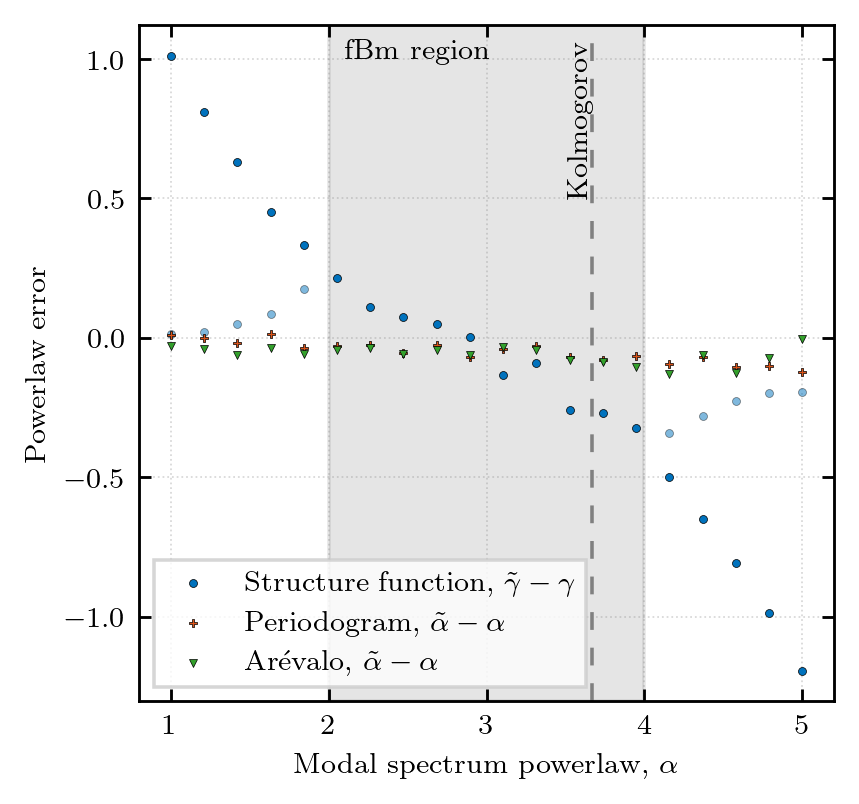

In [85]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in sf_pwrl.keys():
    #ax.scatter(a, pwrl[a][0]/pwrl[a][1], marker='.', s=2., color='black')
    ax.scatter(a, (sf_pwrl[a][0] - sf_pwrl[a][1]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    if sf_pwrl[a][1] < 0.:
        ax.scatter(a, (sf_pwrl[a][0] - 0.), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', alpha=0.5)
    if sf_pwrl[a][1] > 2.:
        ax.scatter(a, (sf_pwrl[a][0] - 2.), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', alpha=0.5)

for a in ek_pwrl.keys():
    ax.scatter(a, (ek_pwrl[a][0] - ek_pwrl[a][1]), marker='P', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

for a in arevalo_pwrl.keys():
    ax.scatter(a, (arevalo_pwrl[a][0] - arevalo_pwrl[a][1]), marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')

ax.scatter([], [], marker='o', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Structure function, $\tilde{\gamma} - \gamma$')
ax.scatter([], [], marker='P', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Periodogram, $\tilde{\alpha} - \alpha$')
ax.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Ar\'evalo, $\tilde{\alpha} - \alpha$')
ax.legend(fancybox=False, frameon=True)

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=1., zorder=0)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(2.1, 0.95, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Powerlaw error')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')


In [88]:

# sf_avg = {}

# for i, ll in enumerate(lsf):
#     l, sf = ll
#     sf_avg[-alphas[i]] = np.nanmean()
    #z, xx, p = fit_base.fit_powerlaw(l, sf, STRFN_MIN, STRFN_MAX)
    #sf_pwrl[-alphas[i]] = (z[0], - alphas[i] - D)

ek_avg = {}

for i, kfek in enumerate(kfeks):
    k, fek = kfek
    ek_avg[-alphas[i]] = (np.nanmean(fek/models[i]), 1.)
    #z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
    #ek_pwrl[-alphas[i]] = (z[0], alphas[i])

arevalo_avg = {}

for i, kfek in enumerate(k_arevaloz):
    k, fek = kfek
    arevalo_avg[-alphas[i]] = (np.nanmean(fek/models[i]), 1.)
    #z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
    #arevalo_pwrl[-alphas[i]] = (z[0], alphas[i])



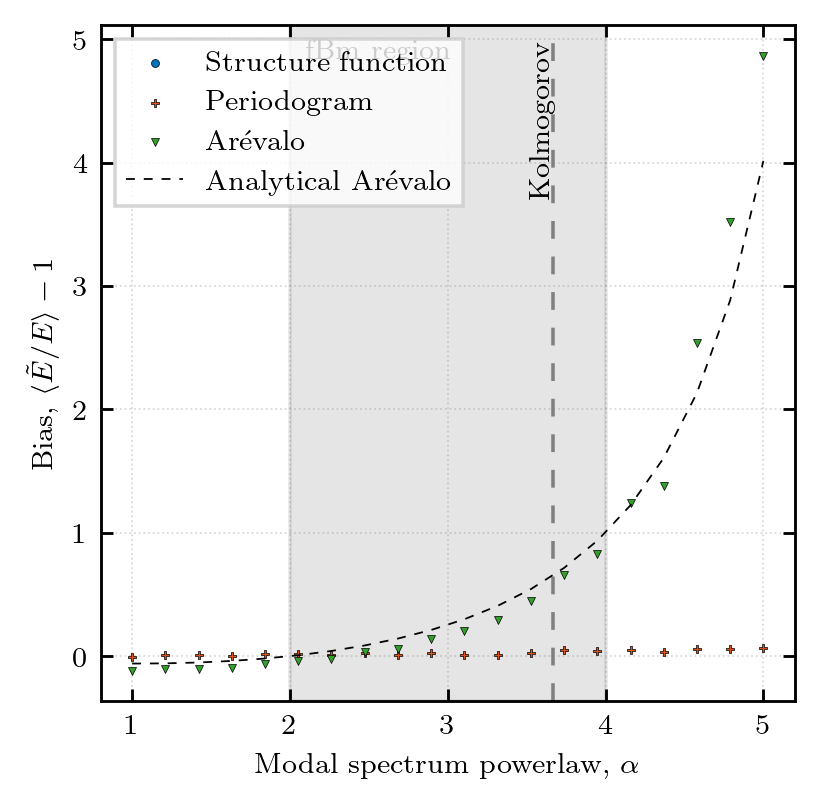

In [102]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in ek_avg.keys():
    ax.scatter(a, ek_avg[a][0] - ek_avg[a][1], marker='P', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

for a in arevalo_avg.keys():
    ax.scatter(a, arevalo_avg[a][0] - arevalo_avg[a][1], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')

from scipy.special import gamma
aa = -alphas
scaling = 2.**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
ax.plot(-alphas, scaling - 1., linewidth=0.5, color='black', linestyle=(0,(5,5)))

ax.scatter([], [], marker='o', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Structure function')
ax.scatter([], [], marker='P', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Periodogram')
ax.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Ar\'evalo')
ax.plot([], [], color='black', linewidth=0.5, linestyle=(0,(5,5)), label=r'Analytical Ar\'evalo')
ax.legend(fancybox=False, frameon=True)

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=1., zorder=0)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(2.1, 0.95, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Bias, $\langle \\tilde{E}(k)/E(k) \\rangle_{k} - 1$')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
